# Homework 2 Complete Solution

**Contents:** Question 1, Parts 1--3; Question 2, Parts 1--3.

## Question 1: Cholesky factorization and repeated solves

### Part 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular
from timeit import repeat

rng = np.random.default_rng(123)
m = 1000
G = rng.normal(size=(m, m))
A = G @ G.T / m
B = rng.normal(size=(m, 40))

L = np.linalg.cholesky(A)
reconstruction_error = np.linalg.norm(A - L @ L.T, "fro") / np.linalg.norm(A, "fro")
smallest_eigenvalue = np.linalg.eigvalsh(A)[0]
print(f"Relative reconstruction error: {reconstruction_error:.3e}")
print(f"Smallest eigenvalue: {smallest_eigenvalue:.3e}")


Relative reconstruction error: 8.389e-16
Smallest eigenvalue: 8.697e-07


The reconstruction error is near machine precision, so $LL^\top$ accurately reproduces $A$. The smallest eigenvalue is positive, confirming that $A$ is positive definite, although its small size indicates that $A$ is ill-conditioned.

### Part 2

In [2]:
Y = solve_triangular(L, B, lower=True)
X_cholesky = solve_triangular(L.T, Y, lower=False)
X_direct = np.linalg.solve(A, B)
relative_residual = np.linalg.norm(A @ X_cholesky - B, "fro") / np.linalg.norm(B, "fro")
relative_difference = np.linalg.norm(X_cholesky - X_direct, "fro") / np.linalg.norm(X_direct, "fro")
print(f"Relative residual: {relative_residual:.3e}")
print(f"Relative difference from np.linalg.solve: {relative_difference:.3e}")


Relative residual: 5.447e-11
Relative difference from np.linalg.solve: 5.428e-11


Both quantities are small, so the Cholesky and general-purpose solves agree closely and satisfy the original linear system accurately.

### Part 3

In [ ]:
def direct_solves():
    return np.column_stack([np.linalg.solve(A, B[:, j]) for j in range(B.shape[1])])

def cholesky_solves():
    factor = np.linalg.cholesky(A)
    intermediate = np.column_stack([solve_triangular(factor, B[:, j], lower=True) for j in range(B.shape[1])])
    result = np.column_stack([solve_triangular(factor.T, intermediate[:, j], lower=False) for j in range(B.shape[1])])
    return result

direct_time = np.median(repeat(direct_solves, number=1, repeat=3))
cholesky_time = np.median(repeat(cholesky_solves, number=1, repeat=3))
print(f"40 separate solves: {direct_time:.3f} seconds")
print(f"Cholesky workflow: {cholesky_time:.3f} seconds")
print(f"Speedup: {direct_time / cholesky_time:.1f} times")


40 separate solves: 0.294 seconds
Cholesky workflow: 0.039 seconds
Speedup: 7.6 times


The separate calls in `direct_solves` repeatedly factor the same matrix. Cholesky factors $A$ once and then uses cheaper triangular solves, so factor reuse is especially valuable when many right-hand sides share the same $A$. Exact timings depend on the computer and numerical libraries.

## Question 2: SVD and PCA

### Part 1

In [13]:
rng = np.random.default_rng(456)
n = 600
latent = rng.normal(size=(n, 2))
loadings = np.array([
    [1.0, 0.9, 0.8, 0.7, 0.0, 0.0, 0.2, 0.1],
    [0.0, 0.0, 0.1, 0.2, 1.0, 0.9, 0.8, 0.7],
])
X = latent @ loadings + 0.15 * rng.normal(size=(n, 8))
group = (latent[:, 0] + latent[:, 1] > 0).astype(int)

X_centered = X - X.mean(axis=0)
U, singular_values, Vt = np.linalg.svd(X_centered, full_matrices=False)
explained_ratio = singular_values**2 / np.sum(singular_values**2)
components_90 = np.argmax(np.cumsum(explained_ratio) >= 0.9) + 1
print("Explained-variance ratios:", np.round(explained_ratio, 4))
print("Components needed for 90%:", components_90)


Explained-variance ratios: [0.5545 0.4227 0.0046 0.004  0.0038 0.0036 0.0035 0.0032]
Components needed for 90%: 2


The first two components explain about 97.7% of the total variance, so two components are sufficient to exceed 90%. This agrees with the construction from two latent factors.

### Part 2

In [ ]:
X_rank2 = (U[:, :2] * singular_values[:2]) @ Vt[:2, :]
reconstruction_error = np.linalg.norm(X_centered - X_rank2, "fro") / np.linalg.norm(X_centered, "fro")
svd_error = np.sqrt(np.sum(singular_values[2:]**2) / np.sum(singular_values**2))
print(f"Direct reconstruction error: {reconstruction_error:.6f}")
print(f"Error from omitted singular values: {svd_error:.6f}")

Direct reconstruction error: 0.150973
Error from omitted singular values: 0.150973


The two values agree to numerical precision. This is because the squared Frobenius reconstruction error equals the sum of the squared singular values omitted from the rank-2 approximation.

### Part 3

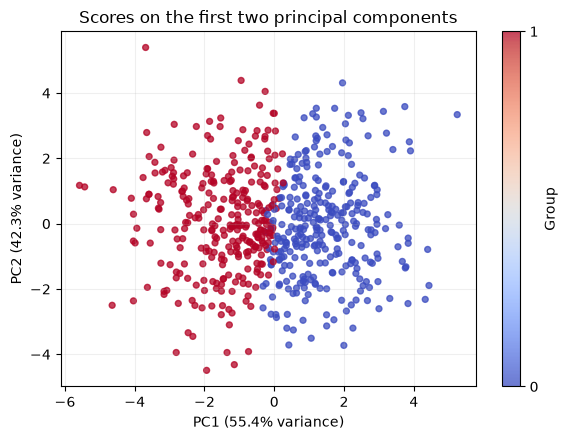

In [6]:
scores = U[:, :2] * singular_values[:2]
plt.figure(figsize=(6, 4.5))
scatter = plt.scatter(scores[:, 0], scores[:, 1], c=group, cmap="coolwarm", s=18, alpha=0.75)
plt.xlabel(f"PC1 ({explained_ratio[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained_ratio[1]:.1%} variance)")
plt.title("Scores on the first two principal components")
plt.colorbar(scatter, label="Group", ticks=[0, 1])
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


The data are effectively two-dimensional because PC1 and PC2 retain nearly all of the variance. The two groups occupy different regions of the score plot, roughly separated by a line but the line is not necessarily $y = -x$ because the two principal components are not necessarily the same as the original two latent variables. In fact, the principal components should be affine transformation of the orignal two variables.